In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Callable, List

# Interactions

In [3]:
df_wo_ts = pd.read_csv("../data/raw/interactions.csv")
df_wo_ts = df_wo_ts.rename(columns={"pfid": "user_id", "anchor_id": "streamer_id"})
df_wo_ts = df_wo_ts[(df_wo_ts["prod_total"] > 0) | (df_wo_ts["consume_cnt"] > 0)] # filter by donations

print(f"Number of rows: {df_wo_ts.shape[0]}")
print(f"Number of columns: {df_wo_ts.shape[1]}")
print(f"Number of unique users: {df_wo_ts['user_id'].nunique()}")
print(f"Number of unique streamers: {df_wo_ts['streamer_id'].nunique()}")


Number of rows: 197010
Number of columns: 11
Number of unique users: 26950
Number of unique streamers: 2952


In [4]:
df_w_ts = pd.read_csv("../data/raw/interactions_w_ts.csv")
df_w_ts = df_w_ts.rename(columns={"pfid": "user_id", "anchor_id": "streamer_id"})
df_w_ts = df_w_ts[(df_w_ts["prod_total"] > 0)] # filter by donations

print(f"Number of rows: {df_w_ts.shape[0]}")
print(f"Number of columns: {df_w_ts.shape[1]}")
print(f"Number of unique users: {df_w_ts['user_id'].nunique()}")
print(f"Number of unique streamers: {df_w_ts['streamer_id'].nunique()}")

Number of rows: 3597850
Number of columns: 7
Number of unique users: 26950
Number of unique streamers: 2952


## Dataset Statistics

### Number of unique (user, streamer) pairs

In [ ]:
def unique_pairs_analysis(df, user_col="user_id", streamer_col="streamer_id"):
    # Count number of unique streamers per user
    user_streamer_counts = df.groupby(user_col)[streamer_col].nunique().reset_index(name="num_streamers")
    print(user_streamer_counts["num_streamers"].describe())

In [ ]:
unique_pairs_analysis(df_wo_ts)

count    26950.000000
mean         7.310204
std         19.104794
min          1.000000
25%          1.000000
50%          1.000000
75%          5.000000
max        486.000000
Name: num_streamers, dtype: float64


In [ ]:
unique_pairs_analysis(df_w_ts)

count    26950.000000
mean         7.310204
std         19.104794
min          1.000000
25%          1.000000
50%          1.000000
75%          5.000000
max        486.000000
Name: num_streamers, dtype: float64


In [ ]:
df_wo_ts[(df_wo_ts["user_id"] == 1000015) & (df_wo_ts["streamer_id"] == 4900393)]

,user_id,streamer_id,is_follow,watch_ts,consume_cnt,prod_total,ent_live_cnt,live_cnt,ent_rate,time_type,group
115,1000015,4900393,1.0,0.0,487.0,756234.0,35.0,41.0,0.853659,H,A


### Distribution of Interacted Streamers per User

In [ ]:
agg = df_w_ts.groupby("user_id")["streamer_id"].nunique().reset_index(name="num_streamers")

In [ ]:
agg

,user_id,num_streamers
0,1000015,16
1,1000033,21
2,1000412,3
3,1000547,1
4,1000888,1
...,...,...
26945,6833070,1
26946,6833090,5
26947,6833117,2
26948,6833119,1


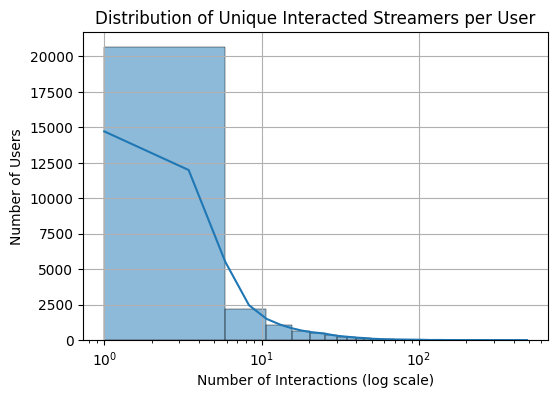

Number of users with 1 streamer: 13667


In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(agg["num_streamers"], bins=100, kde=True)
plt.xscale("log")  # log scale on x-axis
plt.title("Distribution of Unique Interacted Streamers per User")
plt.xlabel("Number of Interactions (log scale)")
plt.ylabel("Number of Users")
plt.grid()
plt.show()

print(f"Number of users with 1 streamer: {agg[agg['num_streamers'] == 1].shape[0]}")

Text(0.5, 1.0, 'Distribution of Users with ≤10 Streamers')

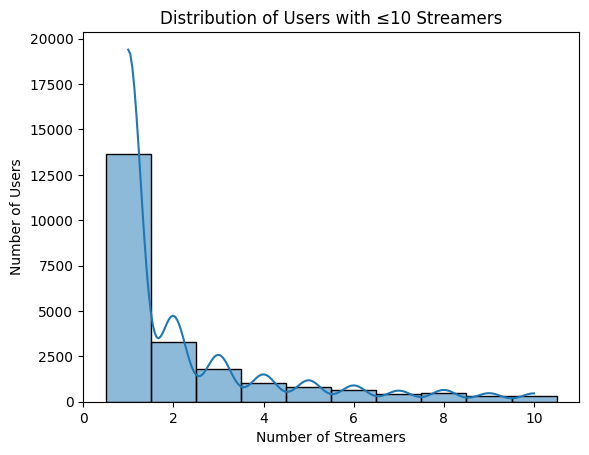

In [72]:
subset = agg[agg["num_streamers"] <= 10]
sns.histplot(subset["num_streamers"], bins=range(1, 11), discrete=True, kde=True)
plt.xlabel("Number of Streamers")
plt.ylabel("Number of Users")
plt.title("Distribution of Users with ≤10 Streamers")


Text(0.5, 1.0, 'Right-tail Distribution (11–486)')

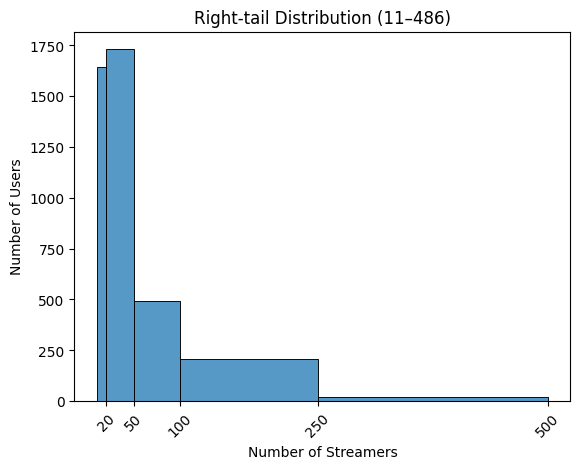

In [89]:
tail = agg[agg["num_streamers"] > 10]
bins = [10, 20, 50, 100, 250, 500]
sns.histplot(tail["num_streamers"], bins=bins, edgecolor="black")
plt.xticks([20, 50, 100, 250, 500], rotation=45)
plt.xlabel("Number of Streamers")
plt.ylabel("Number of Users")
plt.title("Right-tail Distribution (11–486)")

Text(0.5, 1.0, 'Right-tail CCDF of Streamers per User')

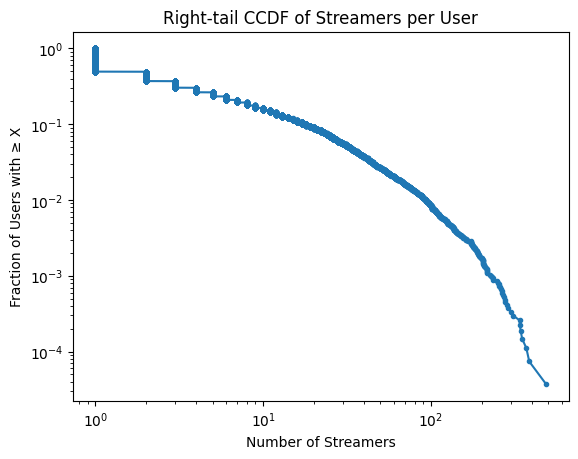

In [76]:
vals = np.sort(agg["num_streamers"])
ccdf = 1 - (np.arange(len(vals)) / len(vals))
plt.loglog(vals, ccdf, marker=".")
plt.xlabel("Number of Streamers")
plt.ylabel("Fraction of Users with ≥ X")
plt.title("Right-tail CCDF of Streamers per User")


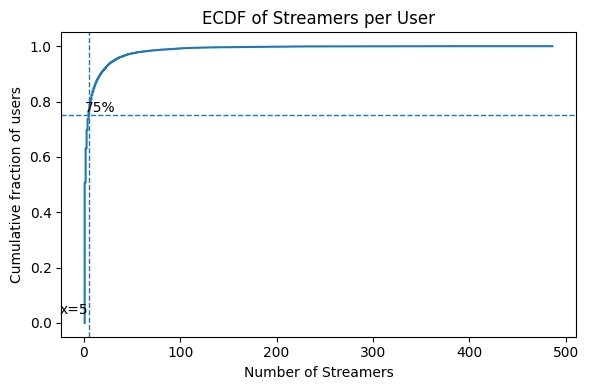

In [91]:
import numpy as np
import matplotlib.pyplot as plt

s = agg["num_streamers"].dropna().astype(float).values
x = np.sort(s)
y = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.axvline(5, ls="--", lw=1)
plt.axhline(0.75, ls="--", lw=1)
plt.text(5, 0.02, "x=5", ha="right", va="bottom")
plt.text(x.min(), 0.75, "75%", va="bottom")
plt.xlabel("Number of Streamers")
plt.ylabel("Cumulative fraction of users")
plt.title("ECDF of Streamers per User")
plt.tight_layout()


### Diversity within Test positives

In [5]:
test_df = pd.read_parquet("../data/splits/donate/w_ts/test.parquet")
test_df = test_df[test_df["label"] == 1]
test_df.shape

(17837, 4)

In [6]:
test_df[test_df["label"] == 1].groupby("streamer_id").size().sort_values(ascending=False).head(10)

streamer_id
1364340    568
4939906    166
1002482    147
6578945    133
1212771    132
1457746    127
1249595    104
4839699     90
6103387     87
1526772     86
dtype: int64

In [7]:
cnt = (
    test_df[test_df["label"] == 1]
      .groupby("streamer_id", sort=False)
      .size()
)
share = cnt / cnt.sum()
share.sort_values(ascending=False).head(10)

streamer_id
1364340    0.031844
4939906    0.009306
1002482    0.008241
6578945    0.007456
1212771    0.007400
1457746    0.007120
1249595    0.005831
4839699    0.005046
6103387    0.004878
1526772    0.004821
dtype: float64

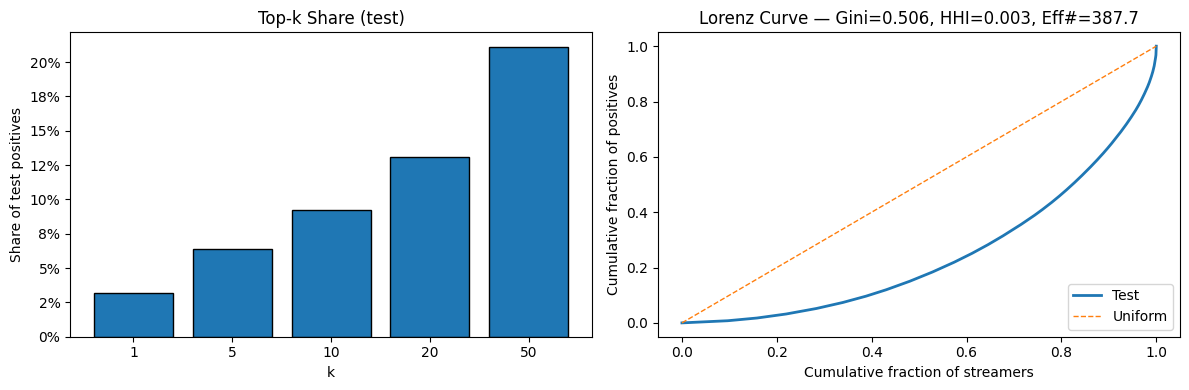

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Assume test_df has columns: 'user_id', 'streamer_id'
test_counts = test_df.groupby("streamer_id").size().sort_values(ascending=False)
p = test_counts / test_counts.sum()  # shares per streamer

def topk_shares(p, ks=(1,5,10,20,50)):
    ps = p.sort_values(ascending=False)
    return {k: float(ps.head(k).sum()) for k in ks if k <= len(ps)}

def gini_from_shares(p):
    # p must sum to 1
    ps = np.sort(p.values)            # ascending
    n = len(ps)
    cum = np.cumsum(ps)
    lorenz_area = cum.sum() / (n)     # trapezoid sum simplified for discrete equal widths
    return 1 - 2 * (lorenz_area / cum[-1]) + 1/n  # exact discrete Gini

def hhi_from_shares(p):
    # HHI in [1/N, 1]; Effective number = 1/HHI
    hhi = float((p**2).sum())
    eff_n = 1.0 / hhi
    # normalized HHI to [0,1]: 0=perfectly even, 1=monopoly
    N = len(p)
    hhi_norm = (hhi - 1/N) / (1 - 1/N)
    return hhi, eff_n, hhi_norm

ks = [1,5,10,20,50]
tk = topk_shares(p, ks)
gini = gini_from_shares(p)
hhi, eff_n, hhi_norm = hhi_from_shares(p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

# (A1) Top-k share bars
ax1.bar([str(k) for k in tk.keys()], list(tk.values()), edgecolor="black")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0%}"))
ax1.set_xlabel("k")
ax1.set_ylabel("Share of test positives")
ax1.set_title("Top-k Share (test)")

# (A2) Lorenz curve
ps = np.sort(p.values)                         # ascending
lorenz = np.r_[0, ps.cumsum()] / ps.sum()
x = np.linspace(0, 1, len(lorenz))
ax2.plot(x, lorenz, label="Test", lw=2)
ax2.plot([0,1],[0,1], "--", lw=1, label="Uniform")
ax2.set_xlabel("Cumulative fraction of streamers")
ax2.set_ylabel("Cumulative fraction of positives")
ax2.set_title(f"Lorenz Curve — Gini={gini:.3f}, HHI={hhi:.3f}, Eff#={eff_n:.1f}")
ax2.legend(loc="lower right")

plt.tight_layout(); plt.show()


## Time-based split

In [9]:
df_train = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts/train.parquet")
df_val = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts/val.parquet")
df_test = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts/test.parquet")

df_repeat = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts/repeat_novel/repeat.parquet")
df_novel = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts/repeat_novel/novel.parquet")

print(f"Number of users in train: {df_train['user_id'].nunique()}")
print(f"Number of streamers in train: {df_train['streamer_id'].nunique()}")
print(f"Number of interactions in train: {df_train.shape[0]}")
print(f"Positives in val: {df_val[df_val['label'] == 1].shape[0]}")
print(f"Positives in test: {df_test[df_test['label'] == 1].shape[0]}")

print(f"Number of users in repeat: {df_repeat['user_id'].nunique()}")
print(f"Number of streamers in repeat: {df_repeat['streamer_id'].nunique()}")

print(f"Number of users in novel: {df_novel['user_id'].nunique()}")
print(f"Number of streamers in novel: {df_novel['streamer_id'].nunique()}")

Number of users in train: 26076
Number of streamers in train: 1624
Number of interactions in train: 455392
Positives in val: 14433
Positives in test: 17837
Number of users in repeat: 12725
Number of streamers in repeat: 1281
Number of users in novel: 5112
Number of streamers in novel: 1097


## Time-based heavy split

In [10]:
df_train = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts_heavy/train.parquet")
df_val = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts_heavy/val.parquet")
df_test = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts_heavy/test.parquet")

df_repeat = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts_heavy/repeat_novel/repeat.parquet")
df_novel = pd.read_parquet("/nas02/home/kevin/recsys_pipeline/data/splits/donate/w_ts_heavy/repeat_novel/novel.parquet")

print(f"Number of users in train: {df_train['user_id'].nunique()}")
print(f"Number of streamers in train: {df_train['streamer_id'].nunique()}")
print(f"Number of interactions in train: {df_train.shape[0]}")
print(f"Positives in val: {df_val[df_val['label'] == 1].shape[0]}")
print(f"Positives in test: {df_test[df_test['label'] == 1].shape[0]}")

print(f"Number of users in repeat: {df_repeat['user_id'].nunique()}")
print(f"Number of streamers in repeat: {df_repeat['streamer_id'].nunique()}")

print(f"Number of users in novel: {df_novel['user_id'].nunique()}")
print(f"Number of streamers in novel: {df_novel['streamer_id'].nunique()}")

Number of users in train: 6861
Number of streamers in train: 1612
Number of interactions in train: 388357
Positives in val: 6861
Positives in test: 6861
Number of users in repeat: 4762
Number of streamers in repeat: 1038
Number of users in novel: 2099
Number of streamers in novel: 748
